In [15]:
%load_ext autoreload
%autoreload 2
import numpy as np
from obstacle import CWObstacle

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# -----------------------------------------------------------------------------
# Physical and orbital parameters (Section IV.A, Table 1)
# -----------------------------------------------------------------------------
mu_E   = 3.986e5          # km^3/s^2, Earth gravitational parameter
R_E    = 6378.0           # km, Earth radius
alt    = 705.0            # km, target altitude
a_orb  = R_E + alt        # km, semi-major axis of target orbit
n_mm   = np.sqrt(mu_E / a_orb**3)   # rad/s, mean motion of target
m_chs  = 6500.0           # kg, chaser mass

# -----------------------------------------------------------------------------
# Discretize with zero-order hold (Section II.B)
# -----------------------------------------------------------------------------
Td = 15.0  # s, sample period (Table 1)

# -----------------------------------------------------------------------------
# Cost weights and Riccati terminal weight
# -----------------------------------------------------------------------------
Q  = np.diag([1, 1, 1, 100, 100, 100])
R  = np.diag([100, 100, 100])

# -----------------------------------------------------------------------------
# MPC parameters
# -----------------------------------------------------------------------------
N            = 30      # horizon length (Table 1)
u_max        = 20.0    # N, per-axis thrust limit
hold_dist    = 2.3     # m, mission terminates within this radius of target
max_steps    = 200     # safety cap
# Initial conditions (Table 1)
x0 = np.array([50.0, -1000.0, 10.0, 0.0, 0.0, 0.0])
xt = np.zeros(6)

# -----------------------------------------------------------------------------
# Obstacle parameters (Section IV.B, Table 2)
# -----------------------------------------------------------------------------
obs1_radius = 20.0   # m, obstacle radius
obs1_pos = np.array([-30.0, -800.0, 10.0])  # m, obstacle position in LVLH frame
obs2_radius = 50.0   # m, obstacle radius
obs2_pos = np.array([-100.0, 0, -40.0])  # m, obstacle position in LVLH frame

In [17]:
cw = CWObstacle(mu_E, R_E, alt, m_chs, Td)
cw.set_cost_params(Q, R)
cw.set_mpc_params(x0, xt, N, u_max, hold_dist, max_steps)
cw.add_obstacle(r_obj=obs1_pos, semi_axes=[obs1_radius]*3)
cw.add_obstacle(r_obj=obs2_pos, semi_axes=[obs2_radius]*3)
cw.simulate()

Reached holding distance (2.046 m) at step 70
Total impulse:   20.10 kN*s
Mean solve time: 2.84 ms / step
Obstacle 0: min Euclidean dist = 30.20 m  (KOZ radius 20 m), min S-metric (>=1) = 1.5101
Obstacle 1: min Euclidean dist = 94.77 m  (KOZ radius 50 m), min S-metric (>=1) = 1.8954


Saved plot to test.png


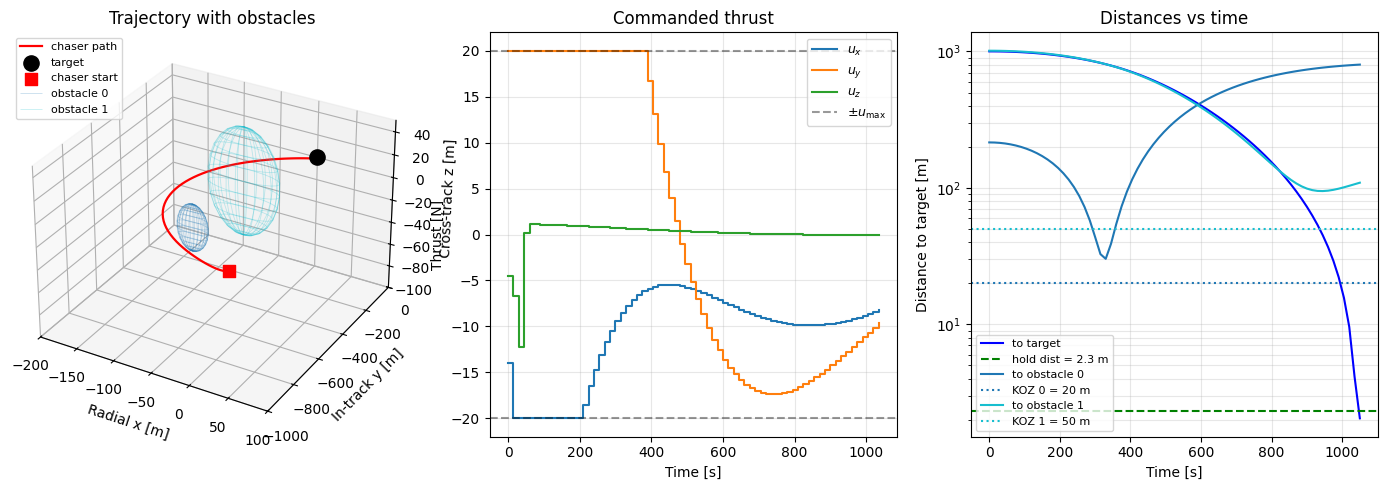

In [18]:
cw.plot_trajectory(cw.trajs, cw.ctrls, filename="test.png")